# **Análisis del crecimiento del Producto Interno Bruto mexicano**
  
El Producto Interno Bruto (PIB) es el indicador de la producción total de los bienes y servicios finales que produce un país en un periodo determinado. Su utilidad radica en que sirve para medir el comportamiento global de una economía.

El análisis busca responder a las siguientes preguntas:
1. ¿Cómo ha evolucionado el PIB?
2. ¿Cuánto ha crecido el PIB en el último trimestre registrado?
3. ¿Cómo ha sido el crecimiento del PIB en los últimos cinco años?

En cuanto a la serie desestacionalizada se busca:
1. ¿Cómo se compara la serie normal con la serie desestacionalizada?
2. ¿Cómo se comparan los crecimientos anuales?
3. ¿Cuánto ha crecido el PIB en su último trimestre respecto al trimestre anterior? 
4. ¿Cómo ha sido el crecimiento del PIB de los últimos 10 trimestres registrados?

Para el siguiente análisis las series a usar son el PIB trimestral a precios de 2018 (precios constantes) y el PIB trimestral a precios de 2018, serie desestacionalizada.

# **Fuente**

- **Serie original:**
    - Fuente: INEGI, Banco de Información Económica (BIE). PIB trimestral a precios de 2018, millones de pesos.

- **Serie desestacionalizada:**
    - Fuente: INEGI, Banco de Información Económica (BIE). PIB trimestral a precios de 2018, serie desestacionalizada, millones de pesos.

Ver `README.md` para el detalle completo de la consulta y notas metodológicas.

In [13]:
# Librerías

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import numpy as np

In [14]:
# Cargar datos

pib_normal = pd.read_csv('../data/pib-precios-2018.csv')
pib_desest = pd.read_csv('../data/pib-precios-2018-desestacionalizada.csv')

# Mostrar datos serie original

pib_normal

,Periodos,PIB
0,1980/01,10401367.61
1,1980/02,10342350.00
2,1980/03,10392733.01
3,1980/04,10927666.35
4,1981/01,11345848.49
...,...,...
181,2025/02,25618678.77
182,2025/03,25422850.19
183,2025/04,26135644.70
184,2026/01,24963384.14


## **Serie original**

### **1. ¿Cómo ha evolucionado el PIB?**

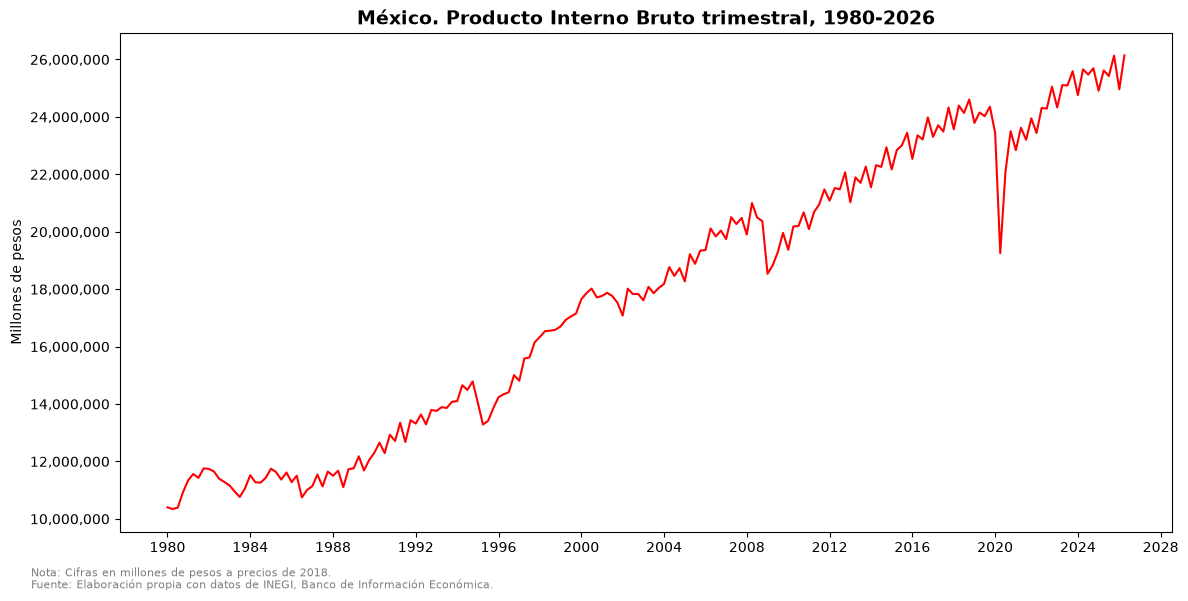

In [15]:
# Gráfica de la evolución del PIB

# 1. Preparación y conversión de los datos

pib_normal['fecha'] = pd.PeriodIndex(pib_normal['Periodos'].str.replace(r'(\d{4})/0?(\d)', r'\1Q\2', regex=True), freq='Q').to_timestamp()

# 2. Creación de la figura y gráfica

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(pib_normal['fecha'], pib_normal['PIB'], color='red')

ax.set_title('México. Producto Interno Bruto trimestral, 1980-2026', fontsize=14, fontweight='bold')

# 3. Configuración de los ejes

# 3.1. Configuración del eje X

ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 3.2. Configuración del eje Y

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
ax.set_ylabel('Millones de pesos')

# 4. Agregar fuente y notas metodológicas

fig.text(0.03, 0.01, 'Fuente: Elaboración propia con datos de INEGI, Banco de Información Económica.', fontsize=8, color='grey', ha='left')
fig.text(0.03, 0.03, 'Nota: Cifras en millones de pesos a precios de 2018.', fontsize=8, color='grey', ha='left')
plt.tight_layout(rect=[0, 0.04, 1, 1])

# 5. Guardar gráfica en directorio figures

plt.savefig('../figures/grafica_01_evolucion_pib.png', dpi=150, bbox_inches='tight')

# 6. Mostrar gráfica

plt.show()

La serie original del PIB muestra una evolución generalmente creciente a lo largo del periodo analizado, con fluctuaciones al alza y a la baja entre trimestres. En general, se observa una tendencia ascendente en el largo plazo.

Asimismo, se identifican cinco contracciones relevantes a lo largo de la serie, cuyos periodos son:
1. **Del cuarto trimestre de 1981 al tercer trimestre de 1983:** la caída se relaciona con la crisis de la deuda externa. La caída de los precios del petróleo y el alza de las tasas de interés internacionales provocan la contracción económica, al volver insostenible el pago de la deuda externa.
2. **Del cuarto trimestre de 1994 al segundo trimestre de 1995:** la caída se relaciona con el llamado "Error de Diciembre" o "Efecto Tequila". La fuga de capitales, el agotamiento de las reservas internacionales y la devaluación del peso, provocan una profunda crisis económica.
3. **Del segundo trimestre de 2001 al primer trimestre de 2002:** la recesión se relaciona con la crisis "dot com" en Estados Unidos. La desaceleración de la economía estadounidense afecta la actividad económica del país.
4. **Del segundo trimestre de 2008 al primer trimestre de 2009:** la caída se relaciona con la crisis financiera global derivada del colapso de la burbuja inmobiliaria (hipotecas subprime) en Estados Unidos. México registra una recesión severa debido a su vinculación comercial y financiera con ese país.
5. **Del cuarto trimestre de 2019 al segundo trimestre de 2020:** la caída se relaciona con la contracción económica por la pandemia de COVID-19, derivada de la suspensión de actividades no esenciales. A esta caída le sigue una recuperación relativamente rápida, reflejada en los dos trimestres siguientes.

Tras esta última contracción y su rápida recuperación, el PIB mexicano regresa en 2022 a niveles similares a los prepandemia, retomando su tendencia ascendente.

### **2. Crecimiento interanual del último trimestre registrado (2T-2026)**

Se compara el mismo trimestre de años consecutivos (en lugar del trimestre inmediato anterior) para evitar el efecto de la estacionalidad, ya que la serie original no está desestacionalizada.

In [16]:
# Crecimiento interanual 2T-2026 vs 2T-2025

# 1. Filtrar los trimestres correspondientes

pib_inter = pib_normal.query('Periodos in ["2025/02", "2026/02"]')

# 2. Crear la columna "Crecimiento_%" y calcular el crecimiento interanual

pib_inter['Crecimiento_%'] = pib_inter['PIB'].pct_change().round(3) * 100

# 3. Mostrar los datos

pib_inter[['Periodos', 'PIB', 'Crecimiento_%']]

,Periodos,PIB,Crecimiento_%
181,2025/02,25618678.77,NaN
185,2026/02,26144132.44,2.1


El PIB registra un crecimiento interanual de 2.1% en el segundo trimestre de 2026, respecto al segundo trimestre de 2025.

### **3. Crecimiento del PIB en los últimos cinco años (2021-2025)**

Para analizar el crecimiento del PIB en los últimos cinco años, se considera el periodo 2021-2025. El PIB anual se calcula mediante el promedio simple de los cuatro trimestres que componen cada año, metodología que retoma el libro *Lo que indican los indicadores* (INEGI).

Para obtener la variación de cada uno de los cinco años, se toma 2020 como año base. Es decir, el crecimiento de 2021 se calcula respecto a 2020, el de 2022 respecto a 2021, y así sucesivamente hasta 2025. De esta forma, aunque la serie abarca datos desde 2020, los valores de crecimiento presentados corresponden únicamente al periodo 2021-2025.

Cabe señalar que, aunque el texto habla de "crecimiento", la gráfica etiqueta el eje Y como **variación porcentual anual (%)**, ya que es la forma estándar de expresar la tasa de cambio del PIB respecto al año anterior.

In [17]:
# Crecimiento del PIB en los últimos cinco años (2021-2025)

# 1. Función para calcular el PIB anual mediante el promedio de los trimestres

def calcular_pib_anual(año):
    
    # 1.1. Filtrar los trimestres que pertenecen al año indicado
    
    pib_filtro = pib_normal[pib_normal['Periodos'].str.startswith(año)]
    
    # 1.2. Calcular el promedio del PIB trimestral para ese año
    
    pib_promedio = pib_filtro['PIB'].mean()
    
    return pib_promedio

# 2. Ejecutar la función a cada año

# 2.1. Definir las listas de trabajo

lista_años = ["2020", "2021", "2022", "2023", "2024", "2025"]   # Años a analizar
resultado_funcion = []   # Lista vacía donde se guarda el PIB anual de cada año

# 2.2. Recorrer la lista de años y almacenar el PIB promedio de cada uno

for año in lista_años:
    resultado_funcion.append(calcular_pib_anual(año))
    
# 3. Crear un nuevo DataFrame con los años y sus respectivos valores de PIB anual

pib_anual = pd.DataFrame({'Año': lista_años, 'PIB': resultado_funcion})
pib_anual['PIB'] = pib_anual['PIB'].round(2)

# 4. Calcular el crecimiento anual del PIB en la columna "Crecimiento_%"

pib_anual['Crecimiento_%'] = (pib_anual['PIB'].pct_change() * 100).round(1)

# 5. Mostrar los datos

pib_anual

,Año,PIB,Crecimiento_%
0,2020,22069934.76,NaN
1,2021,23404831.12,6.0
2,2022,24273093.50,3.7
3,2023,25031031.64,3.1
4,2024,25396468.50,1.5
5,2025,25522695.98,0.5


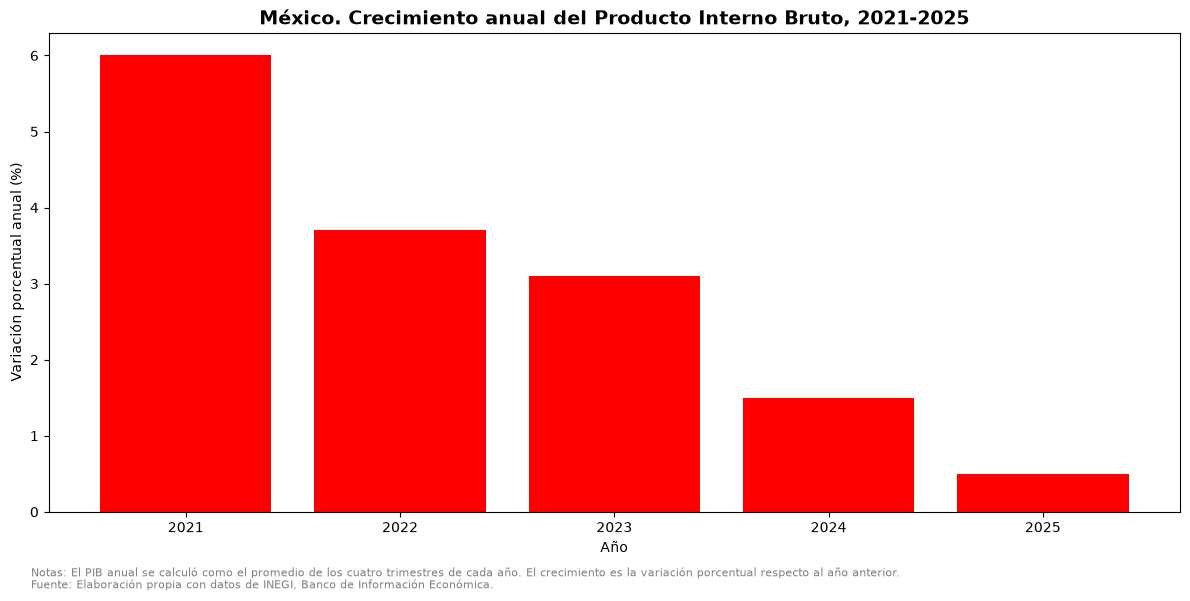

In [18]:
# Gráfica del crecimiento anual del PIB

# 1. Crear la figura y la gráfica de barras

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(pib_anual['Año'], pib_anual['Crecimiento_%'], color='red')

ax.set_title('México. Crecimiento anual del Producto Interno Bruto, 2021-2025', fontsize=14, fontweight='bold')

# 2. Configurar los ejes

# 2.1. Eje X

ax.set_xlabel('Año')

# 2.2. Eje Y

ax.set_ylabel('Variación porcentual anual (%)')

# 3. Agregar fuente y notas metodológicas

fig.text(0.03, 0.01, 'Fuente: Elaboración propia con datos de INEGI, Banco de Información Económica.', fontsize=8, color='grey', ha='left')
fig.text(0.03, 0.03, 'Notas: El PIB anual se calculó como el promedio de los cuatro trimestres de cada año. El crecimiento es la variación porcentual respecto al año anterior.', fontsize=8, color='grey', ha='left')
plt.tight_layout(rect=[0, 0.04, 1, 1])

# 4. Guardar gráfica en el directorio figures

plt.savefig('../figures/grafica_02_crecimiento_pib_anual.png', dpi=150, bbox_inches='tight')

# 5. Mostrar gráfica

plt.show()

El crecimiento del PIB mexicano se desacelera año con año durante el periodo analizado (2021-2025). El periodo muestra tres etapas: un fuerte repunte en 2021, un crecimiento moderado en 2022 y 2023, y un crecimiento bajo en 2024 y 2025.

El año con mayor crecimiento es 2021, cuando el PIB aumenta 6.0% con respecto a 2020. Este resultado se explica en buena parte por el efecto rebote tras la reapertura económica posterior a la pandemia de COVID-19, amplificado por el hecho de que 2020, el año base, fue de caída profunda.

El año con menor crecimiento es 2025, cuando el PIB aumenta 0.5% con respecto a 2024, un nivel cercano al estancamiento.

En resumen, tras el repunte de 2021 (6.0%), las tasas de 2022 (3.7%) y 2023 (3.1%) son moderadas, y las de 2024 (1.5%) y 2025 (0.5%) caen a niveles bajos. Aunque el PIB no se contrae en ninguno de los años analizados, el ritmo de expansión se debilita cada año.

## **Serie desestacionalizada**

Para analizar el comportamiento del PIB sin la distorsión de patrones recurrentes, se recurre a la serie desestacionalizada. A esta serie se le eliminan las variaciones estacionales y los efectos de calendario, con el fin de facilitar la comparación entre periodos, ya que así reflejan únicamente cambios económicos y no patrones repetitivos. En México, las variaciones estacionales pueden deberse a factores como la Semana Santa, los días festivos o el aumento de la actividad económica durante diciembre.

Esta serie permite comparar cada trimestre contra su inmediato anterior (t vs. t-1), algo que no es válido hacer con la serie original sin desestacionalizar.

*Nota: los datos de 1993 a 2026 son preliminares. Ver README para más detalle.*

### **1. ¿Cómo ha evolucionado el PIB? (comparación con la serie original)**

Se compara la serie desestacionalizada contra la serie original para identificar qué patrones se confirman y qué cambia el remover el componente estacional.

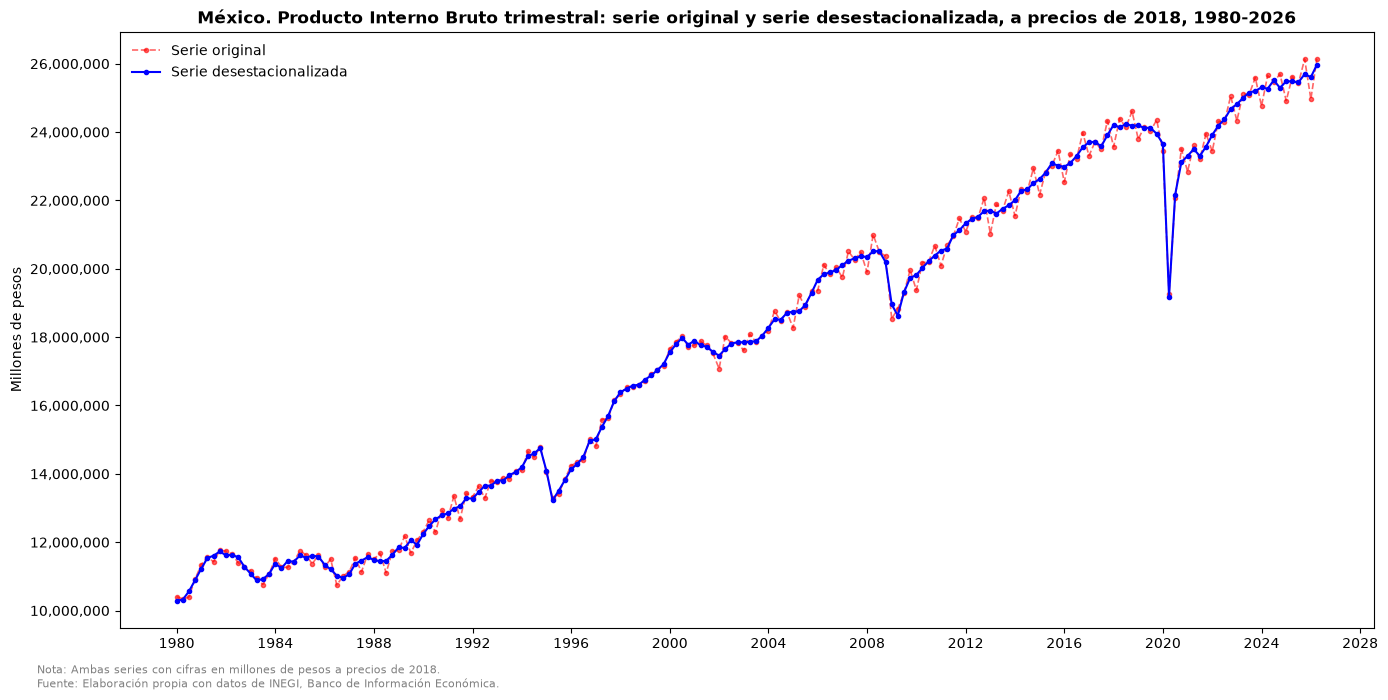

In [19]:
# Gráfica de la evolución del PIB (serie original y serie desestacionalizada)

# 1. Preparación y conversión de los datos desestacionalizados

pib_desest['fecha'] = pd.PeriodIndex(pib_desest['Periodos'].str.replace(r'(\d{4})/0?(\d)', r'\1Q\2', regex=True), freq='Q').to_timestamp()

# 2. Crear la figura y la gráfica

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(pib_normal['fecha'], pib_normal['PIB'], linestyle='--', color='red', marker='.', linewidth=1.2, alpha=0.6, zorder=1, label='Serie original')
ax.plot(pib_desest['fecha'], pib_desest['PIB'], color='blue', marker='.', linewidth=1.5, zorder=2, label='Serie desestacionalizada')

ax.set_title('México. Producto Interno Bruto trimestral: serie original y serie desestacionalizada, a precios de 2018, 1980-2026', fontsize=12, fontweight='bold')

# 3. Configurar los ejes

# 3.1. Eje X

ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 3.2. Eje Y

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
ax.set_ylabel('Millones de pesos')

# 4. Agregar leyenda

ax.legend(loc='upper left', frameon=False, fontsize=10)

# 5. Agregar fuente y nota metodológica

fig.text(0.03, 0.01, 'Fuente: Elaboración propia con datos de INEGI, Banco de Información Económica.', fontsize=8, color='grey', ha='left')
fig.text(0.03, 0.03, 'Nota: Ambas series con cifras en millones de pesos a precios de 2018.', fontsize=8, color='grey', ha='left')

plt.tight_layout(rect=[0, 0.04, 1, 1])

# 6. Guardar gráfica en el directorio figures

plt.savefig('../figures/grafica_03_comparacion_series.png', dpi=150, bbox_inches='tight')

# 7. Mostrar gráfica

plt.show()

Al comparar ambas series, se observa que la serie desestacionalizada conserva la tendencia creciente de largo plazo de la serie original, pero con una trayectoria más suave, ya que elimina las oscilaciones regulares (estacionales) que se repiten cada año. Esto permite apreciar con mayor claridad la dirección del PIB entre trimestres consecutivos.

La serie desestacionalizada confirma las cinco contracciones que se identifican en la serie original, lo cual es lo esperado, pues la desestacionalización elimina el componente estacional, no los efectos de las crisis. 

Los periodos en la serie desestacionalizada son:
1. **Crisis de la deuda externa:** del segundo trimestre de 1982 al segundo trimestre de 1983.
2. **Efecto Tequila:** del cuarto trimestre de 1994 al segundo trimestre de 1995.
3. **Crisis "dot com":** del primer trimestre de 2001 al primer trimestre de 2002.
4. **Crisis financiera global:** del tercer trimestre de 2008 al segundo trimestre de 2009.
5. **Pandemia de COVID-19:** del tercer trimestre de 2019 al segundo trimestre de 2020.

Aunque las caídas son las mismas, los periodos difieren hasta dos trimestres respecto a la serie original, salvo el Efecto Tequila, que coincide en ambas. Esto ocurre porque el efecto estacional puede adelantar o retrasar el trimestre en que aparecen el máximo y el mínimo de cada caída. Por ejemplo, en la crisis "dot com", la serie original ubica el inicio de la caída en el segundo trimestre de 2001, mientras que la desestacionalizada lo ubica en el primer trimestre de 2001, es decir, la original atrasa el inicio un trimestre, y el final coincide (primer trimestre de 2002). En cambio, en la crisis financiera global, la serie original abarca del segundo trimestre de 2008 al primer trimestre de 2009, y la desestacionalizada del tercer trimestre de 2008 al segundo trimestre de 2009, es decir, la original adelanta toda la caída un trimestre.

Además, la serie desestacionalizada permite identificar una contracción adicional, que las oscilaciones estacionales enmascaran en la serie original: del tercer trimestre de 1985 al cuarto trimestre de 1986, con cinco trimestres consecutivos de contracción. Esta caída se relaciona con el desplome de los precios del petróleo en 1986, el impacto del sismo de 1985 y la alta inflación de esos años. También muestra un estancamiento con ligera tendencia a la baja antes de la pandemia, sobre la cual la pandemia de COVID-19 provoca una caída abrupta.

En conclusión, la serie original sirve para conocer el nivel observado del PIB, pero sus oscilaciones estacionales dificultan identificar con precisión el inicio y el fin de las caídas. La serie desestacionalizada es más adecuada para delimitar los periodos de contracción y recuperación, y para analizar la evolución de largo plazo del PIB mexicano.

### **2. ¿Cómo se comparan los crecimientos anuales?**

Se anualiza el PIB desestacionalizado con el mismo método usado en la serie original (promedio simple de los cuatro trimestres) y se compara contra los resultados ya obtenidos, a manera de validación cruzada: dado que al promediar los cuatro trimestres el efecto estacional tiende a cancelarse, se espera que ambos resultados sean muy similares.

In [20]:
# Comparación de los crecimientos anuales: serie original vs serie desestacionalizada (2021-2025)

# 1. Función para calcular el PIB anual desestacionalizado mediante el promedio de los trimestres

def calcular_pib_anual_desest(año):
    
    # 1.1. Filtrar los trimestres que pertenecen al año indicado
    
    pib_filtro = pib_desest[pib_desest['Periodos'].str.startswith(año)]
    
    # 1.2. Calcular el promedio del PIB trimestral para ese año
    
    pib_promedio = pib_filtro['PIB'].mean()
    
    return pib_promedio

# 2. Ejecutar la función a cada año

# 2.1. Definir la lista vacía donde se guarda el PIB anual desestacionalizado de cada año

resultado_funcion_desest = [] 

# 2.2. Recorrer la lista de años y almacenar el PIB promedio de cada uno

for año in lista_años:
    resultado_funcion_desest.append(calcular_pib_anual_desest(año))
    
# 3. Crear un nuevo DataFrame con los años y sus respectivos valores de PIB anual

pib_anual_desest = pd.DataFrame({'Año': lista_años, 'PIB_desest': resultado_funcion_desest})
pib_anual_desest['PIB_desest'] = pib_anual_desest['PIB_desest'].round(2)

# 4. Calcular el crecimiento anual del PIB en la columna "Crecimiento_desest_%"

pib_anual_desest['Crecimiento_desest_%'] = (pib_anual_desest['PIB_desest'].pct_change() * 100).round(1)

# 5. Copiar la columna "Crecimiento_%" de pib_anual como "Crecimiento_original_%"
# (.values evita desalineamientos de índice; ambos DataFrames tienen los mismos años en el mismo orden)

pib_anual_desest['Crecimiento_original_%'] = pib_anual['Crecimiento_%'].values

# 6. Calcular la diferencia entre ambos crecimientos (en puntos porcentuales)

pib_anual_desest['Diferencia_pp'] = (pib_anual_desest['Crecimiento_desest_%'] - pib_anual_desest['Crecimiento_original_%']).round(1)

# 7. Mostrar los datos

pib_anual_desest[['Año', 'Crecimiento_original_%', 'Crecimiento_desest_%', 'Diferencia_pp']]

,Año,Crecimiento_original_%,Crecimiento_desest_%,Diferencia_pp
0,2020,NaN,NaN,NaN
1,2021,6.0,6.3,0.3
2,2022,3.7,3.7,0.0
3,2023,3.1,3.1,0.0
4,2024,1.5,1.2,-0.3
5,2025,0.5,0.7,0.2


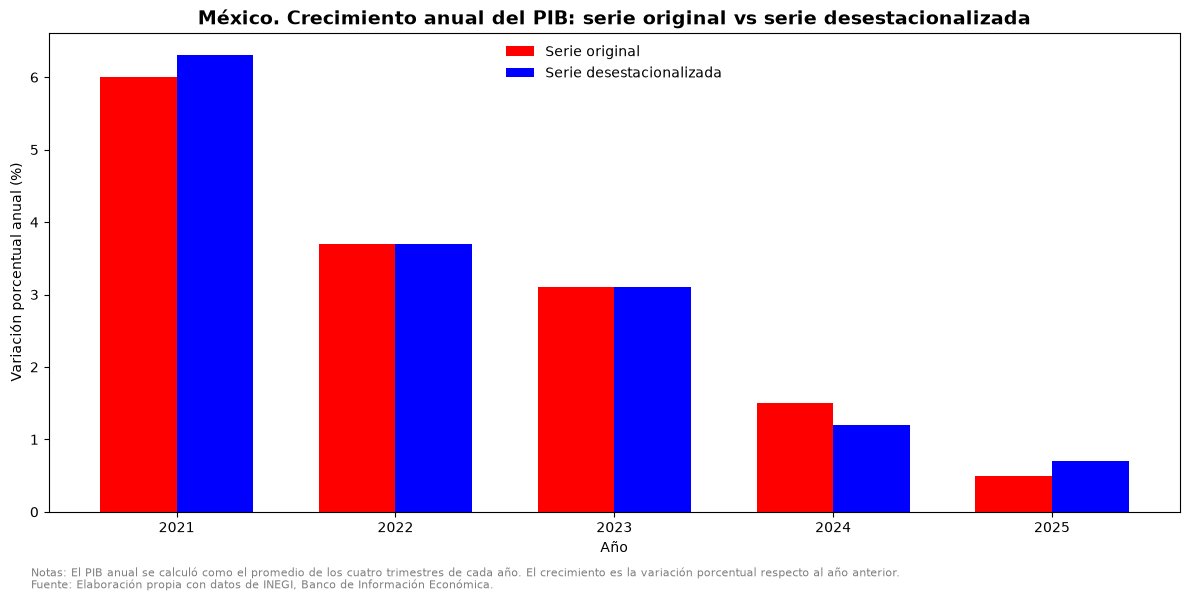

In [21]:
# Gráfica comparación del crecimiento anual del PIB: serie original vs serie desestacionalizada

# 1. Quitar el año base (2020), ya que no tiene valor

comparacion_barras = pib_anual_desest.dropna(subset=['Crecimiento_desest_%'])

# 2. Definir posiciones numéricas y ancho de las barras

posiciones = np.arange(len(comparacion_barras))
ancho = 0.35

# 3. Crear la figura y la gráfica de barras

fig, ax= plt.subplots(figsize=(12, 6))

ax.bar(posiciones - ancho/2, comparacion_barras['Crecimiento_original_%'], color='red', width=ancho, label='Serie original')
ax.bar(posiciones + ancho/2, comparacion_barras['Crecimiento_desest_%'], color='blue', width=ancho, label='Serie desestacionalizada')

ax.set_title('México. Crecimiento anual del PIB: serie original vs serie desestacionalizada', fontsize=14, fontweight='bold')

# 4. Configurar los ejes

# 4.1. Eje X

ax.set_xlabel('Año')

# 4.2. Eje Y

ax.set_ylabel('Variación porcentual anual (%)')

# 5. Colocar los años como etiquetas del eje X

ax.set_xticks(posiciones)
ax.set_xticklabels(comparacion_barras['Año'])

# 6. Agregar leyenda

ax.legend(loc='upper center', frameon=False, fontsize=10)

# 7. Agregar fuente y notas metodológicas

fig.text(0.03, 0.01, 'Fuente: Elaboración propia con datos de INEGI, Banco de Información Económica.', fontsize=8, color='grey', ha='left')
fig.text(0.03, 0.03, 'Notas: El PIB anual se calculó como el promedio de los cuatro trimestres de cada año. El crecimiento es la variación porcentual respecto al año anterior.', fontsize=8, color='grey', ha='left')

plt.tight_layout(rect=[0, 0.04, 1, 1])

# 8. Guardar gráfica en el directorio figures

plt.savefig('../figures/grafica_04_comparacion_crecimiento_anual_series.png', dpi=150, bbox_inches='tight')

# 9. Mostrar gráfica

plt.show()

Los crecimientos anuales de ambas series son muy similares y confirman la misma lectura, un fuerte repunte en 2021, un crecimiento moderado en 2022 y 2023, y un crecimiento bajo en 2024 y 2025. En ambas series el ritmo de expansión se desacelera cada año.

Las tasas coinciden en 2022 (3.7%) y 2023 (3.1%). En los otros tres años las diferencias son pequeñas y no superan 0.3 puntos porcentuales: en 2021 la serie desestacionalizada crece 6.3% frente a 6.0% de la original (0.3 p.p.), en 2024 crece 1.2% frente a 1.5% (-0.3 p.p.) y en 2025 crece 0.7% frente a 0.5% (0.2 p.p.).

Este resultado confirma lo esperado, al promediar los cuatro trimestres de cada año, el efecto estacional tiende a cancelarse, pues la desestacionalización afecta principalmente a los datos trimestrales. Por ello, ambas series arrojan crecimientos anuales prácticamente iguales, y el resultado valida el cálculo con la serie original. Las pequeñas diferencias no alteran la conclusión de la primera parte, el crecimiento se desacelera de forma continua, desde el repunte de 2021 hasta el crecimiento más bajo en 2025.

### **3. Crecimiento del último trimestre respecto a su inmediato anterior (2T-2026 vs 1T-2026)**

A diferencia de la serie original, en la serie desestacionalizada sí es válido comparar un trimestre contra el inmediato anterior, ya que el componente estacional ya fue removido.

In [22]:
# Crecimiento del último trimestre con respecto al inmediato anterior (2T-2026 vs 1T-2026)

# 1. Filtrar para obtener únicamente los últimos dos trimestres

ultimos_trimestres = pib_desest.query('Periodos in ["2026/01", "2026/02"]')

# 2. Calcular el crecimiento trimestral en la columna "Crecimiento_trimestral"

ultimos_trimestres['Crecimiento_trimestral'] = (ultimos_trimestres['PIB'].pct_change() * 100).round(1)

# 3. Mostrar los resultados

ultimos_trimestres[['Periodos', 'PIB', 'Crecimiento_trimestral']]

,Periodos,PIB,Crecimiento_trimestral
184,2026/01,25606452.75,NaN
185,2026/02,25971192.58,1.4


En el segundo trimestre de 2026, el PIB desestacionalizado registra un crecimiento de 1.4% con respecto al trimestre anterior. Este resultado indica una expansión de la actividad económica en el trimestre.

### **4. Crecimiento trimestral en los últimos 10 trimestres (1T-2024 a 2T-2026)**

In [23]:
# Crecimiento de los último 10 trimestres (1T-2024 a 2T-2026)

# 1. Calcular el crecimiento trimestral en la columna "Crecimiento_trimestral" para toda la serie

pib_desest['Crecimiento_trimestral'] = pib_desest['PIB'].pct_change() * 100

# 2. Filtrar para obtener los últimos 10 trimestres

trimestres = pib_desest[pib_desest['Periodos'].str.startswith(("2024", "2025", "2026"))]

# 3. Redondear y eliminar el signo negativo del cero

trimestres['Crecimiento_trimestral'] = trimestres['Crecimiento_trimestral'].round(1) + 0.0

# 4. Mostrar los resultados

trimestres[['Periodos', 'PIB', 'Crecimiento_trimestral']]

,Periodos,PIB,Crecimiento_trimestral
176,2024/01,25306022.44,0.4
177,2024/02,25266256.67,-0.2
178,2024/03,25515285.34,1.0
179,2024/04,25290826.80,-0.9
180,2025/01,25486696.26,0.8
181,2025/02,25480578.99,0.0
182,2025/03,25453873.70,-0.1
183,2025/04,25694485.95,0.9
184,2026/01,25606452.75,-0.3
185,2026/02,25971192.58,1.4


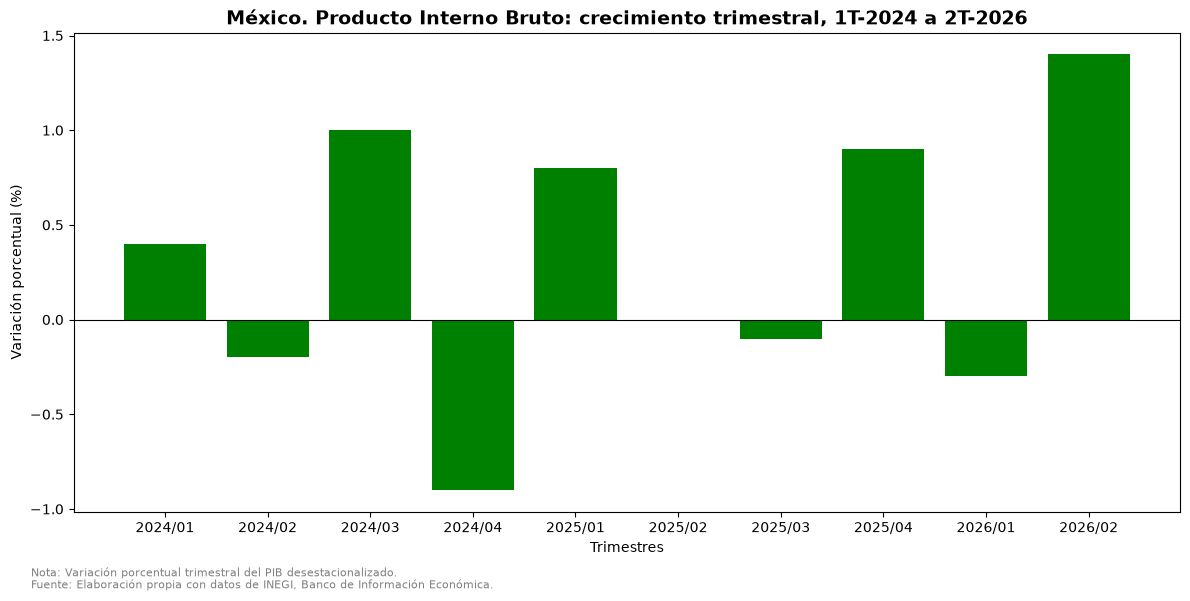

In [24]:
# Gráfica crecimiento de los últimos 10 trimestres (1T-2024 a 2T-2026)

# 1. Crear la figura y la gráfica

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(trimestres['Periodos'], trimestres['Crecimiento_trimestral'], color='green')

ax.axhline(0, color='black', linewidth=0.8)

ax.set_title('México. Producto Interno Bruto: crecimiento trimestral, 1T-2024 a 2T-2026', fontsize=14, fontweight='bold')

# 2. Configurar los ejes

# 2.1. Eje X

ax.set_xlabel('Trimestres')

# 2.2. Eje Y

ax.set_ylabel('Variación porcentual (%)')

# 3. Agregar fuente y notas metodológicas

fig.text(0.03, 0.01, 'Fuente: Elaboración propia con datos de INEGI, Banco de Información Económica.', fontsize=8, color='grey', ha='left')
fig.text(0.03, 0.03, 'Nota: Variación porcentual trimestral del PIB desestacionalizado.', fontsize=8, color='grey', ha='left')
plt.tight_layout(rect=[0, 0.04, 1, 1])

# 4. Guardar gráfica en el directorio figures

plt.savefig('../figures/grafica_05_crecimiento_trimestral_desestacionalizado.png', dpi=150, bbox_inches='tight')

# 5. Mostrar gráfica

plt.show()

El trimestre con mayor crecimiento es el segundo de 2026, con 1.4% respecto al trimestre anterior. El trimestre con la mayor caída es el cuarto de 2024, con -0.9%.

En el periodo analizado el crecimiento del PIB es oscilante, del primer trimestre de 2024 al segundo trimestre de 2026, los trimestres alternan entre alzas y bajas, y ninguna tendencia se sostiene por más de un trimestre.

Las variaciones son pequeñas, a excepción del repunte de 1.4% en el segundo trimestre de 2026, que revierte la caída de -0.3% en el primer trimestre de 2026 y supera cualquier otra alza del periodo.

El caso del segundo trimestre de 2025 es particular. Al calcular la variación porcentual y redondear a un decimal, el resultado es 0.0, pero con más decimales corresponde a una caída de -0.02%. Para este análisis se usa el valor de 0.0, que coincide con el publicado por el INEGI.

## **Conclusiones**

El PIB de México muestra una tendencia creciente de largo plazo, interrumpida por seis contracciones: cinco visibles en la serie original y una sexta, de 1985 a 1986, que solo la serie desestacionalizada permite identificar. Estas caídas se relacionan con crisis internas y choques externos. La más reciente, la pandemia de COVID-19, va seguida de una recuperación rápida, y en 2022 el PIB regresa a niveles similares a los prepandemia.

En los últimos cinco años, el crecimiento anual se desacelera: tras el fuerte repunte de 2021 (6.0%), el PIB crece de forma moderada en 2022 y 2023, y de forma baja en 2024 y 2025 (0.5%, cercano al estancamiento). En el segundo trimestre de 2026, el PIB crece 2.1% respecto al mismo trimestre de 2025 (serie original) y 1.4% respecto al trimestre anterior (serie desestacionalizada). Este último es el mayor avance de los últimos 10 trimestres, que en general alternan entre alzas y bajas pequeñas. Un solo trimestre no basta para hablar de un cambio de tendencia.

En cuanto a las series, ambas muestran la misma tendencia y producen crecimientos anuales muy similares (diferencias de hasta 0.3 puntos porcentuales), porque el efecto estacional tiende a cancelarse al promediar los cuatro trimestres. La serie original sirve para conocer el nivel observado y el crecimiento anual; la desestacionalizada es más adecuada para comparar trimestres consecutivos y delimitar los periodos de contracción y recuperación.